# Λογιστική Παλινδρόμηση και Softmax

Σε αυτό το notebook θα εξερευνήσουμε τη λογιστική παλινδρόμηση και την εφαρμογή της χρησιμοποιώντας τόσο το scikit-learn όσο και το PyTorch. Θα δούμε:

1. Δημιουργία και οπτικοποίηση διαχωρίσιμων δεδομένων
2. Εφαρμογή λογιστικής παλινδρόμησης με scikit-learn
3. Περιστροφή των δεδομένων και επανεφαρμογή
4. Δημιουργία μη διαχωρίσιμων δεδομένων
5. Υλοποίηση με PyTorch
6. Αλλαγή της συνάρτησης απώλειας


```
Κωνσταντίνος Καραμανής: constantine@utexas.edu
http://users.ece.utexas.edu/~cmcaram/
The University of Texas at Austin
Archimedes/Athena RC
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
# Generate separable data
np.random.seed(42)
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)
print(type(X))
# Scale the data to make it more visually appealing
X = X / 2

<class 'numpy.ndarray'>


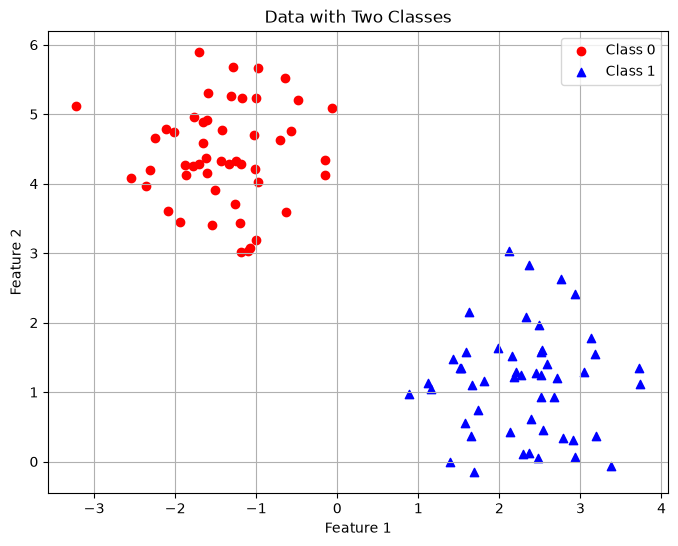

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data with Two Classes')
plt.legend()
plt.grid(True)
plt.show()

## 3. Εφαρμογή Λογιστικής Παλινδρόμησης

Θα χρησιμοποιήσουμε το scikit-learn για να εφαρμόσουμε τη λογιστική παλινδρόμηση. Το μοντέλο θα βρει το βέλτιστο υπερεπίπεδο διαχωρισμού μεταξύ των δύο κλάσεων. Στο γράφημα, η περιοχή διαχωρισμού (decision boundary) φαίνεται με διαφορετικά χρώματα.

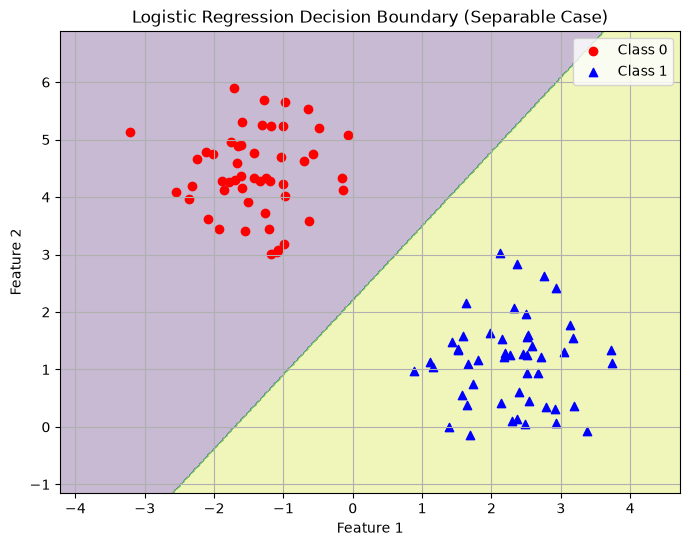

In [ ]:
# Fit logistic regression
model_log_reg = LogisticRegression(random_state=42)
help(model_log_reg)
model_log_reg.fit(X, y)

# Create a mesh grid for plotting decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for the mesh grid
Z = model_log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary (Separable Case)')
plt.legend()
plt.grid(True)
plt.show()

## 4. Περιστροφή των Δεδομένων

Θα περιστρέψουμε τα δεδομένα κατά 45 μοίρες με τη χρήση πίνακα περιστροφής:

$$R = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

όπου $\theta = \frac{\pi}{4}$ (45 μοίρες).

Πώς αντιμετωπίζει διαφορετικούς προσανατολισμούς η λογιστική παλινδρόμηση;

**Ξέρουμε ήδη**:
* Ο βασικός μαθηματικός υπολογισμός που χρησιμοποιεί η λογιστική παλινδρόμηση είναι το εσωτερικό γινόμενο.
* Το εσωτερικό γινόμενο εξαρτάται μόνο από την γωνία μεταξύ δύο δυανυσμάτων.
* Η γωνία δεν αλλάζει, εφόσον περιστρέφουμε όλα τα δεδομένα μαζί.
* **Οπότε**: περιμένουμε πως η λύση της λογιστικής παλινδρόμησης στα δεδομένα που περιστρέψαμε, θα είναι ακριβώς η περιστροφή της αρχικής λύσης.

In [6]:
## Πίνακας Περιστροφής
theta = np.pi/4  # 45 degrees
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                           [np.sin(theta), np.cos(theta)]])
X_rotated = X @ rotation_matrix

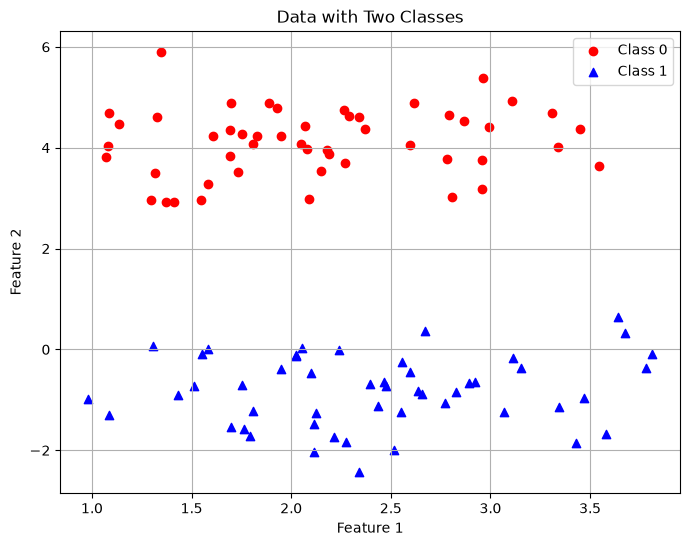

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X_rotated[y==0, 0], X_rotated[y==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_rotated[y==1, 0], X_rotated[y==1, 1], c='blue', marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data with Two Classes')
plt.legend()
plt.grid(True)
plt.show()

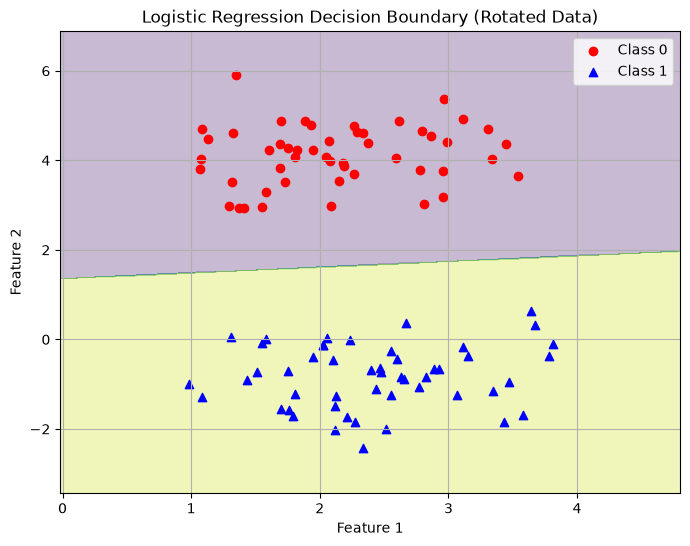

In [8]:
# Fit logistic regression on rotated data
model_log_reg_rotated = LogisticRegression(random_state=42)
model_log_reg_rotated.fit(X_rotated, y)

# Create mesh grid for rotated data
x_min, x_max = X_rotated[:, 0].min() - 1, X_rotated[:, 0].max() + 1
y_min, y_max = X_rotated[:, 1].min() - 1, X_rotated[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for the mesh grid
Z = model_log_reg_rotated.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_rotated[y==0, 0], X_rotated[y==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_rotated[y==1, 0], X_rotated[y==1, 1], c='blue', marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary (Rotated Data)')
plt.legend()
plt.grid(True)
plt.show()

## Περιστρέφεται και η λύση

Όταν περιτρέφουμε τα δεδομένα, μπορούμε να δούμε πως και η λύση έχει περιστραφεί με ακριβώς τον ίδιο τρόπο.

In [9]:
beta_original = model_log_reg.coef_[0]
beta_rotated = model_log_reg_rotated.coef_[0]
print("Original Beta Coefficients:", beta_original)
print("Rotated Beta Coefficients:", beta_rotated)

Original Beta Coefficients: [ 1.68213881 -1.30108815]
Rotated Beta Coefficients: [ 0.26944351 -2.10946001]


In [10]:
# multiple beta_original by the rotation matrix
beta_rotated_multi = beta_original @ rotation_matrix
print("Rotated Beta Coefficients (multiple by R):", beta_rotated_multi)

Rotated Beta Coefficients (multiple by R): [ 0.26944351 -2.10946001]


## 5. Μη Διαχωρίσιμα Δεδομένα

Τώρα θα δημιουργήσουμε ένα σύνολο δεδομένων με μεγαλύτερη επικάλυψη μεταξύ των κλάσεων. Αυτό επιτυγχάνεται αυξάνοντας την τυπική απόκλιση των συστάδων (`cluster_std`). Σε αυτή την περίπτωση, η λογιστική παλινδρόμηση θα πρέπει να βρει το καλύτερο δυνατό διαχωριστικό υπερεπίπεδο, ακόμα κι αν υπάρχουν κάποια λανθασμένα ταξινομημένα σημεία.

In [11]:
# Generate data with more overlap
X_noisy, y_noisy = make_blobs(n_samples=100, centers=2, random_state=42,
                              cluster_std=3.5)
X_noisy = X_noisy / 2

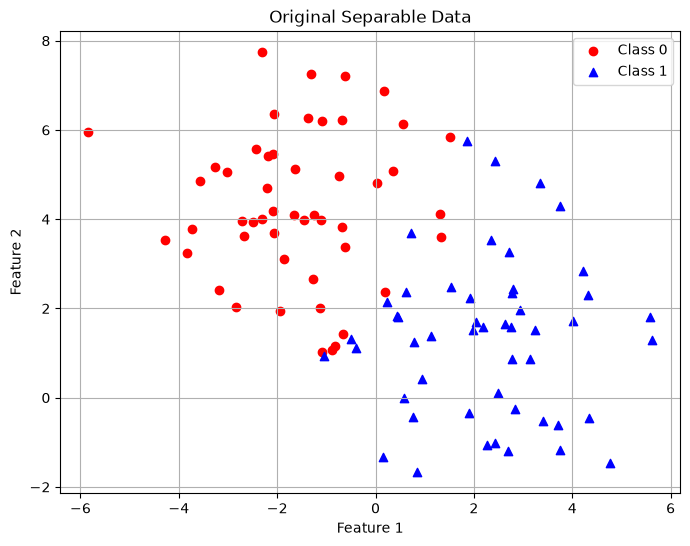

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_noisy[y_noisy==0, 0], X_noisy[y_noisy==0, 1], c='red',
            marker='o', label='Class 0')
plt.scatter(X_noisy[y_noisy==1, 0], X_noisy[y_noisy==1, 1], c='blue',
            marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original Separable Data')
plt.legend()
plt.grid(True)
plt.show()

## 6. Λογιστική Παλινδρόμηση σε Μη Διαχωρίσιμα Δεδομένα

Παρατηρήστε πώς το μοντέλο προσπαθεί να βρει το βέλτιστο υπερεπίπεδο διαχωρισμού, ακόμα κι αν υπάρχει επικάλυψη μεταξύ των κλάσεων. Οι περιοχές με διαφορετικά χρώματα δείχνουν τις προβλέψεις του μοντέλου.

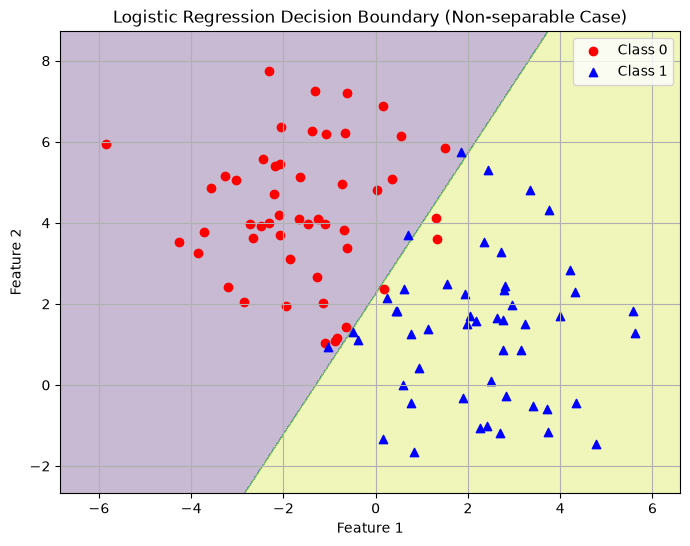

In [13]:
# Fit logistic regression on non-separable data
model_log_reg = LogisticRegression(random_state=42)
model_log_reg.fit(X_noisy, y_noisy)

# Create mesh grid
x_min, x_max = X_noisy[:, 0].min() - 1, X_noisy[:, 0].max() + 1
y_min, y_max = X_noisy[:, 1].min() - 1, X_noisy[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for the mesh grid
Z = model_log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_noisy[y_noisy==0, 0], X_noisy[y_noisy==0, 1], c='red',
            marker='o', label='Class 0')
plt.scatter(X_noisy[y_noisy==1, 0], X_noisy[y_noisy==1, 1], c='blue',
            marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary (Non-separable Case)')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Generate data with more overlap
X_noisy, y_noisy = make_blobs(n_samples=100, centers=2, random_state=42,
                              cluster_std=3.5)
X_noisy = X_noisy / 2

# Add a small cluster of red points (class 0) in a tight cloud
n_misclassified = 12  # number of points to add
center_x, center_y = 5.75, -1.5  # center of the new cluster
std = 0.1  # small standard deviation for tight clustering

# Generate the new points
new_points = np.random.normal(
    loc=[center_x, center_y],
    scale=[std, std],
    size=(n_misclassified, 2)
)

# Add these points to the dataset
X_noisy = np.vstack([X_noisy, new_points])
y_noisy = np.concatenate([y_noisy, np.zeros(n_misclassified)])  # zeros for class 0 (red)

## Πως αλλάζει το βέλτιστο υπερεπίπεδο διαχωρισμού


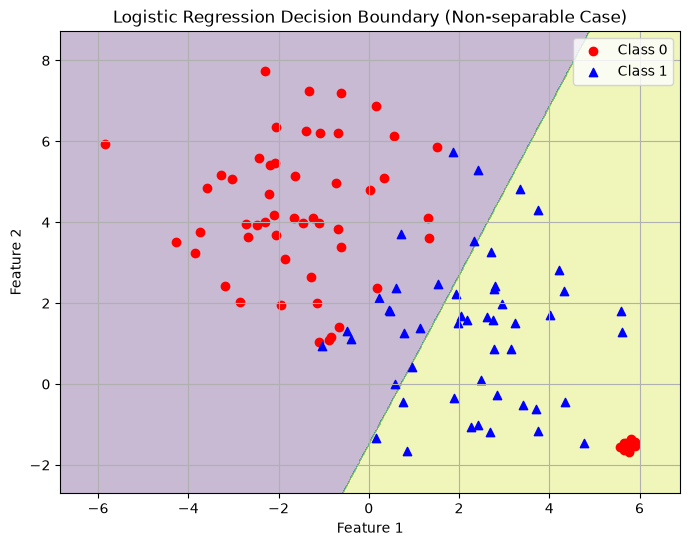

In [15]:
# Fit logistic regression on non-separable data
model_log_reg = LogisticRegression(random_state=42)
model_log_reg.fit(X_noisy, y_noisy)

# Create mesh grid
x_min, x_max = X_noisy[:, 0].min() - 1, X_noisy[:, 0].max() + 1
y_min, y_max = X_noisy[:, 1].min() - 1, X_noisy[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for the mesh grid
Z = model_log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_noisy[y_noisy==0, 0], X_noisy[y_noisy==0, 1], c='red',
            marker='o', label='Class 0')
plt.scatter(X_noisy[y_noisy==1, 0], X_noisy[y_noisy==1, 1], c='blue',
            marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary (Non-separable Case)')
plt.legend()
plt.grid(True)
plt.show()

## 7. Υλοποίηση με PyTorch και Softmax

Στη συνέχεια θα υλοποιήσουμε την ίδια λογιστική παλινδρόμηση χρησιμοποιώντας το PyTorch και τη συνάρτηση softmax. Το softmax είναι μια γενίκευση της σιγμοειδούς συνάρτησης για πολλαπλές κλάσεις.

### Μαθηματική Συνάρτηση Softmax

Η συνάρτηση softmax ορίζεται ως:

$$P(y=j|x) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}$$

όπου:
- $z_j$ είναι το σκορ για την κλάση $j$
- $K$ είναι ο αριθμός των κλάσεων
- Το αποτέλεσμα είναι η πιθανότητα να ανήκει ένα σημείο στην κλάση $j$

In [16]:
class SimpleLogisticNN(nn.Module):
    def __init__(self):
        super(SimpleLogisticNN, self).__init__()
        self.linear = nn.Linear(2, 2)

    def forward(self, x):
        x = self.linear(x)
        return x

In [17]:
# Convert data to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y)  # LongTensor for CrossEntropyLoss

# Create dataset and dataloader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [18]:
# Initialize model, loss function, and optimizer
model = SimpleLogisticNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Training loop
n_epochs = 1000
for epoch in range(n_epochs):
    for X_batch, y_batch in dataloader:
        # Forward pass
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.0060
Epoch [200/1000], Loss: 0.0008
Epoch [300/1000], Loss: 0.0024
Epoch [400/1000], Loss: 0.0036
Epoch [500/1000], Loss: 0.0000
Epoch [600/1000], Loss: 0.0014
Epoch [700/1000], Loss: 0.0004
Epoch [800/1000], Loss: 0.0005
Epoch [900/1000], Loss: 0.0003
Epoch [1000/1000], Loss: 0.0002


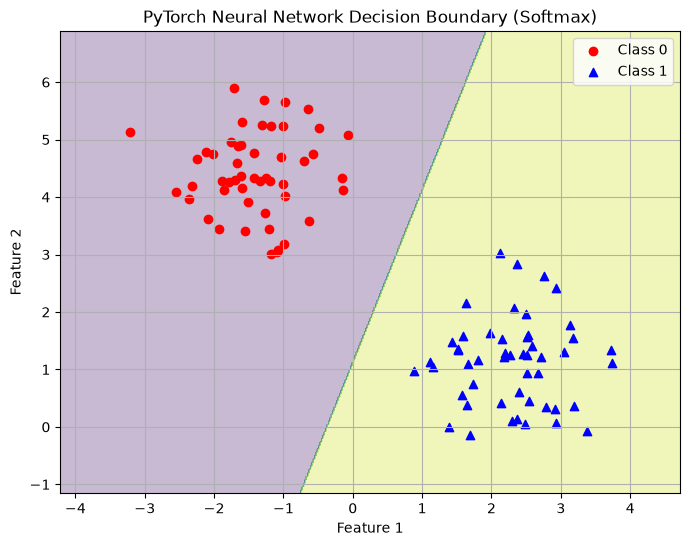

In [19]:
# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for the mesh grid
with torch.no_grad():
    mesh_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    Z = model(mesh_tensor)
    Z = torch.argmax(Z, dim=1).numpy()  # Get the class with highest probability
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('PyTorch Neural Network Decision Boundary (Softmax)')
plt.legend()
plt.grid(True)
plt.show()

## 8. Αλλάζουμε την συνάρτηση απώλειας

Θα δοκιμάσουμε το ``Hinge Loss`` με την εντολή

``
criterion = nn.MarginRankingLoss(margin=margin)
``

Αυτή η συνάρτηση απόωλειας έχει την μορφή:
$$
Loss(y,z) = max(0,1-yz)
$$
ή γενικότερα
$$
Loss(y,z) = max(0,m-yz)
$$


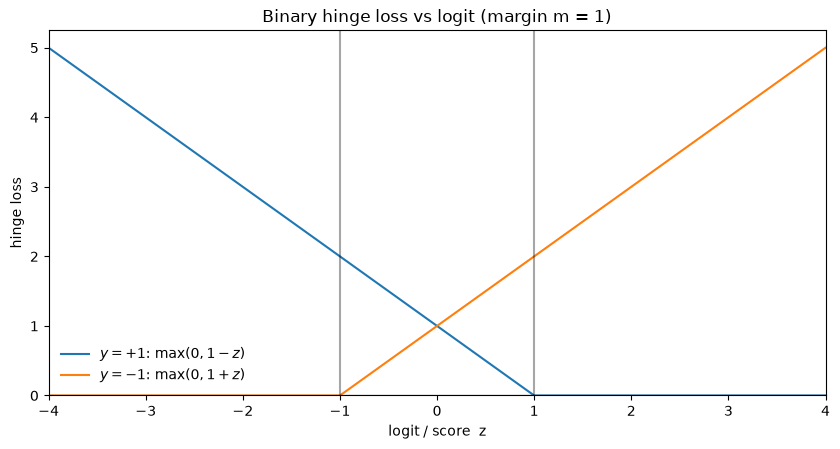

In [20]:
import numpy as np
import matplotlib.pyplot as plt
# --- Hinge loss vs logit (margin m = 1) ---
# Binary hinge: L(z, y) = max(0, m - y*z), with y in {-1, +1}

m = 1.0
z = np.linspace(-4, 4, 1200)  # logits / scores

loss_y_pos = np.maximum(0.0, m - (1.0 * z))   # y = +1
loss_y_neg = np.maximum(0.0, m - (-1.0 * z))  # y = -1

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(z, loss_y_pos, label=r"$y=+1$: $\max(0, 1 - z)$", color="#1f77b4")
ax.plot(z, loss_y_neg, label=r"$y=-1$: $\max(0, 1 + z)$", color="#ff7f0e")

ax.axvline(+m, color="black", lw=1.5, alpha=0.35)
ax.axvline(-m, color="black", lw=1.5, alpha=0.35)
ax.axhline(0.0, color="black", lw=1.0, alpha=0.35)

ax.set_title("Binary hinge loss vs logit (margin m = 1)")
ax.set_xlabel("logit / score  z")
ax.set_ylabel("hinge loss")
ax.set_xlim(z.min(), z.max())
ax.set_ylim(0, max(loss_y_pos.max(), loss_y_neg.max()) * 1.05)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


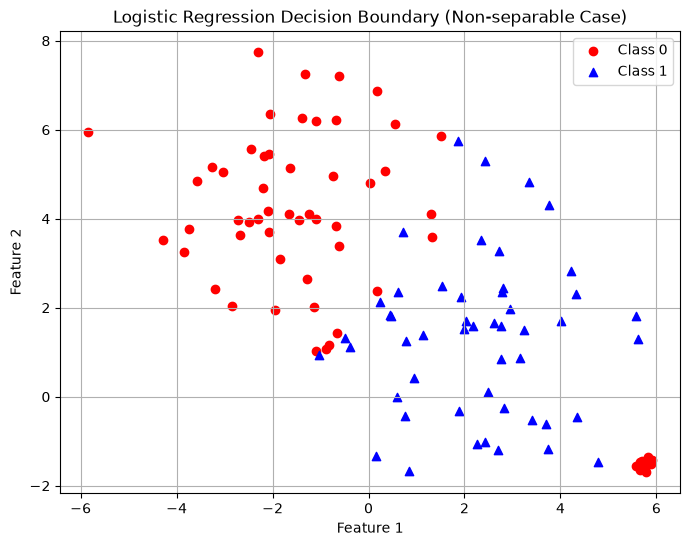

In [21]:
# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(X_noisy[y_noisy==0, 0], X_noisy[y_noisy==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_noisy[y_noisy==1, 0], X_noisy[y_noisy==1, 1], c='blue', marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary (Non-separable Case)')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Convert data to PyTorch tensors
X_noisy_tensor = torch.FloatTensor(X_noisy)
y_noisy_tensor = torch.LongTensor(y_noisy)  # Changed to LongTensor for CrossEntropyLoss

# Create dataset and dataloader
dataset_noisy = TensorDataset(X_noisy_tensor, y_noisy_tensor)
dataloader_noisy = DataLoader(dataset_noisy, batch_size=32, shuffle=True)

In [23]:
# Initialize model, loss function, and optimizer
model = SimpleLogisticNN()

margin = 1.0  # hinge margin m (use 0.01 if you really want a tiny margin)
criterion = nn.MarginRankingLoss(margin=margin)  # implements max(0, m - y*z) via comparison vs 0
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Training loop
n_epochs = 1000
for epoch in range(n_epochs):
    for X_batch, y_batch in dataloader:
        logits = model(X_batch)

        # Convert model output to a single score z per sample
        # If model outputs 2 logits (batch,2), use z = logit1 - logit0
        if logits.ndim == 2 and logits.shape[1] == 2:
            z = logits[:, 1] - logits[:, 0]      # (batch,)
        else:
            z = logits.view(-1)                  # (batch,)

        # Make labels shape (batch,) and convert 0/1 -> -1/+1
        if y_batch.ndim > 1:                     # e.g. one-hot (batch,2)
            y_idx = y_batch.argmax(dim=1)
        else:
            y_idx = y_batch.view(-1)

        y = y_idx.float() * 2.0 - 1.0            # (batch,), values -1 or +1

        zeros = torch.zeros_like(z)
        loss = criterion(z, zeros, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}")

Epoch [100/1000], Loss: 0.0000
Epoch [200/1000], Loss: 0.0000
Epoch [300/1000], Loss: 0.0000
Epoch [400/1000], Loss: 0.0000
Epoch [500/1000], Loss: 0.0000
Epoch [600/1000], Loss: 0.0000
Epoch [700/1000], Loss: 0.0000
Epoch [800/1000], Loss: 0.0000
Epoch [900/1000], Loss: 0.0000
Epoch [1000/1000], Loss: 0.0000


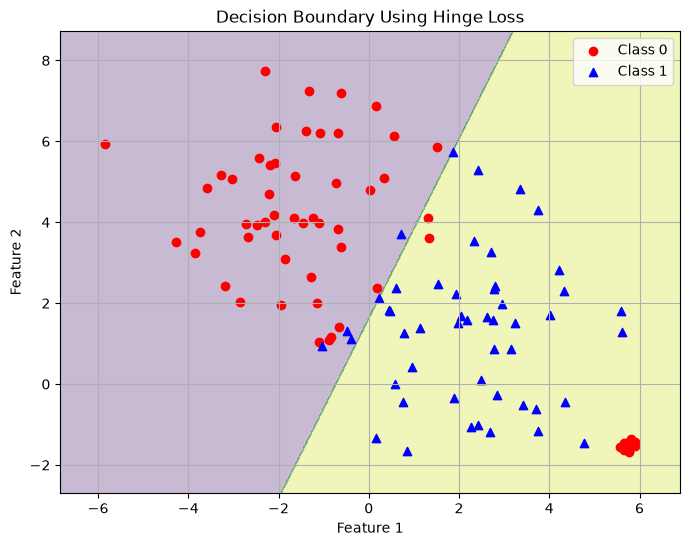

In [24]:
# Create mesh grid
x_min, x_max = X_noisy[:, 0].min() - 1, X_noisy[:, 0].max() + 1
y_min, y_max = X_noisy[:, 1].min() - 1, X_noisy[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for the mesh grid
with torch.no_grad():
    mesh_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    Z = model(mesh_tensor)
    Z = torch.argmax(Z, dim=1).numpy()  # Get the class with highest probability
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_noisy[y_noisy==0, 0], X_noisy[y_noisy==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_noisy[y_noisy==1, 0], X_noisy[y_noisy==1, 1], c='blue', marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary Using Hinge Loss')
plt.legend()
plt.grid(True)
plt.show()

## Cross Entropy

In [25]:
# Initialize model, loss function, and optimizer
model = SimpleLogisticNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Training loop
n_epochs = 1000
for epoch in range(n_epochs):
    for X_batch, y_batch in dataloader_noisy:
        # Forward pass
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.5768
Epoch [200/1000], Loss: 0.6447
Epoch [300/1000], Loss: 0.5859
Epoch [400/1000], Loss: 0.5439
Epoch [500/1000], Loss: 0.6276
Epoch [600/1000], Loss: 0.4822
Epoch [700/1000], Loss: 0.6046
Epoch [800/1000], Loss: 0.5103
Epoch [900/1000], Loss: 0.6115
Epoch [1000/1000], Loss: 0.5435


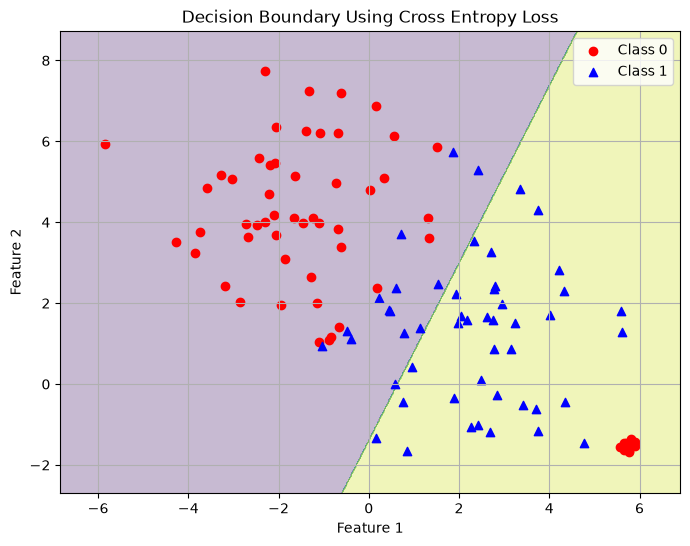

In [26]:
# Create mesh grid
x_min, x_max = X_noisy[:, 0].min() - 1, X_noisy[:, 0].max() + 1
y_min, y_max = X_noisy[:, 1].min() - 1, X_noisy[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for the mesh grid
with torch.no_grad():
    mesh_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    Z = model(mesh_tensor)
    Z = torch.argmax(Z, dim=1).numpy()  # Get the class with highest probability
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_noisy[y_noisy==0, 0], X_noisy[y_noisy==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_noisy[y_noisy==1, 0], X_noisy[y_noisy==1, 1], c='blue', marker='^', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary Using Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

## 8. Τριών Κλάσεων Λογιστική Παλινδρόμηση με PyTorch

Στη συνέχεια θα δούμε πώς μπορούμε να υλοποιήσουμε λογιστική παλινδρόμηση για τρεις κλάσεις χρησιμοποιώντας το PyTorch. Θα χρησιμοποιήσουμε:
- Κόκκινες κουκκίδες για την κλάση 0
- Μπλε τρίγωνα για την κλάση 1
- Μαύρα τετράγωνα για την κλάση 2

In [27]:
# Generate three-class data
np.random.seed(42)
X_3class, y_3class = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=1.5)
X_3class = X_3class / 2  # Scale the data

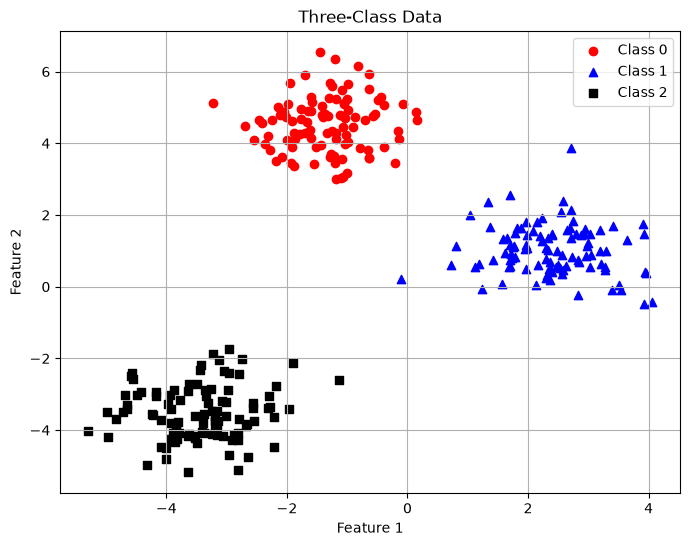

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(X_3class[y_3class==0, 0], X_3class[y_3class==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_3class[y_3class==1, 0], X_3class[y_3class==1, 1], c='blue', marker='^', label='Class 1')
plt.scatter(X_3class[y_3class==2, 0], X_3class[y_3class==2, 1], c='black', marker='s', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Three-Class Data')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
class ThreeClassLogisticNN(nn.Module):
    def __init__(self):
        super(ThreeClassLogisticNN, self).__init__()
        self.linear = nn.Linear(2, 3)

    def forward(self, x):
        x = self.linear(x)
        return x

In [30]:
# Convert data to PyTorch tensors
X_3class_tensor = torch.FloatTensor(X_3class)
y_3class_tensor = torch.LongTensor(y_3class)

# Create dataset and dataloader
dataset_3class = TensorDataset(X_3class_tensor, y_3class_tensor)
dataloader_3class = DataLoader(dataset_3class, batch_size=32, shuffle=True)

In [31]:
# Initialize model, loss function, and optimizer
model_3class = ThreeClassLogisticNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_3class.parameters(), lr=0.1)

# Training loop
n_epochs = 1000
for epoch in range(n_epochs):
    for X_batch, y_batch in dataloader_3class:
        # Forward pass
        y_pred = model_3class(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.0041
Epoch [200/1000], Loss: 0.0468
Epoch [300/1000], Loss: 0.0009
Epoch [400/1000], Loss: 0.0007
Epoch [500/1000], Loss: 0.0010
Epoch [600/1000], Loss: 0.0020
Epoch [700/1000], Loss: 0.0002
Epoch [800/1000], Loss: 0.0001
Epoch [900/1000], Loss: 0.0006
Epoch [1000/1000], Loss: 0.0003


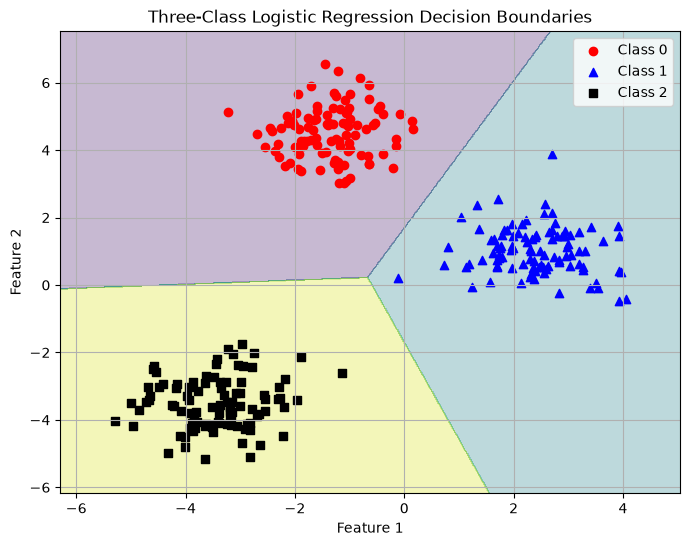

In [32]:
# Create mesh grid
x_min, x_max = X_3class[:, 0].min() - 1, X_3class[:, 0].max() + 1
y_min, y_max = X_3class[:, 1].min() - 1, X_3class[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get predictions for the mesh grid
with torch.no_grad():
    mesh_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    Z = model_3class(mesh_tensor)
    Z = torch.argmax(Z, dim=1).numpy()  # Get the class with highest probability
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_3class[y_3class==0, 0], X_3class[y_3class==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_3class[y_3class==1, 0], X_3class[y_3class==1, 1], c='blue', marker='^', label='Class 1')
plt.scatter(X_3class[y_3class==2, 0], X_3class[y_3class==2, 1], c='black', marker='s', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Three-Class Logistic Regression Decision Boundaries')
plt.legend()
plt.grid(True)
plt.show()

### Σημειώσεις για την Τριών Κλάσεων Υλοποίηση

Στη τριών κλάσεων περίπτωση:
- Το μοντέλο μας επιστρέφει 3 εξόδους (μία για κάθε κλάση)
- Το softmax μετατρέπει αυτές τις εξόδους σε πιθανότητες
- Η περιοχή διαχωρισμού (decision boundary) αποτελείται τώρα από τρία διαφορετικά χρώματα
- Κάθε χρώμα αντιπροσωπεύει την περιοχή όπου η αντίστοιχη κλάση έχει την υψηλότερη πιθανότητα

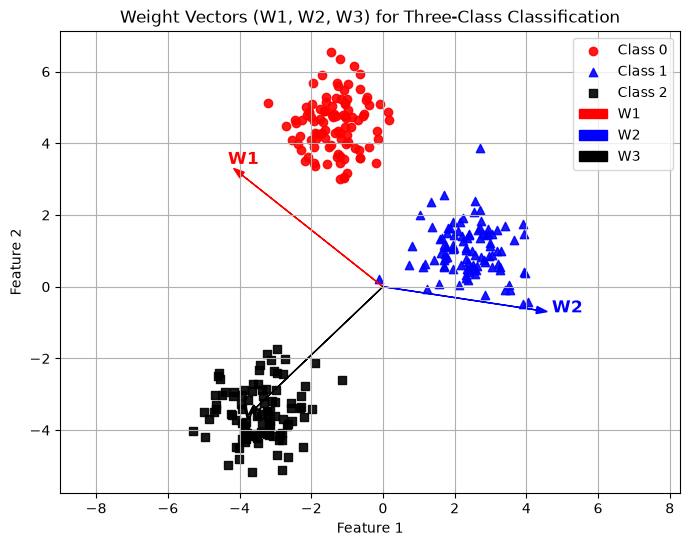

In [33]:
# Get the weight vectors from the trained model
weights = model_3class.linear.weight.data.numpy()

# nn.linear(2,3)

# Create a new figure
plt.figure(figsize=(8, 6))

# Plot the data points
plt.scatter(X_3class[y_3class==0, 0], X_3class[y_3class==0, 1], c='red', marker='o', label='Class 0', alpha=0.9)
plt.scatter(X_3class[y_3class==1, 0], X_3class[y_3class==1, 1], c='blue', marker='^', label='Class 1', alpha=0.9)
plt.scatter(X_3class[y_3class==2, 0], X_3class[y_3class==2, 1], c='black', marker='s', label='Class 2', alpha=0.9)

# Plot the weight vectors as arrows from the origin
colors = ['red', 'blue', 'black']
for i, (w, c) in enumerate(zip(weights, colors)):
    # Scale the arrow for better visualization
    scale = 2.0
    plt.arrow(0, 0, w[0]*scale, w[1]*scale,
              head_width=0.2, head_length=0.3, fc=c, ec=c,
              label=f'W{i+1}')
    # Add text label at the end of the arrow
    plt.text(w[0]*scale*1.1, w[1]*scale*1.1, f'W{i+1}',
             color=c, fontsize=12, fontweight='bold')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Weight Vectors (W1, W2, W3) for Three-Class Classification')
plt.grid(True)
plt.axis('equal')  # Make the plot square to preserve vector directions
plt.legend()
plt.show()

# 10 Κατηγορίες  

Οι ίδιες ιδέες ισχύουν και για πιο πολλές κατηγορίες. Περνάμε τώρα σε ένα πρόβλημα ταξινόμησης με 10 κατηγορίες. Παρατηρούμε:

* Το νευρωνικό δίκτυο είναι παρόμοιο. Το ουσιαστικό στοιχείο είναι το γραμμικό επίπεδο της λογιστικής παλινδρόμησης:

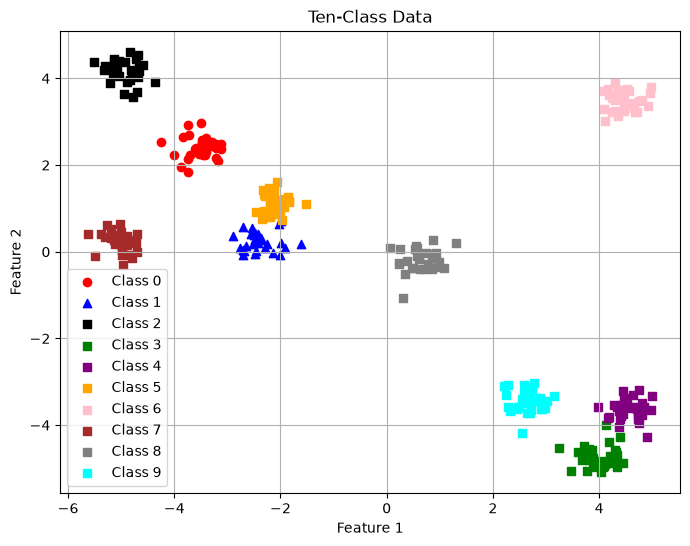

In [34]:
# Generate three-class data
np.random.seed(42)
X_10class, y_10class = make_blobs(n_samples=300, centers=10, random_state=12,
                                  cluster_std=0.5)
X_10class = X_10class / 2  # Scale the data

plt.figure(figsize=(8, 6))
plt.scatter(X_10class[y_10class==0, 0], X_10class[y_10class==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_10class[y_10class==1, 0], X_10class[y_10class==1, 1], c='blue', marker='^', label='Class 1')
plt.scatter(X_10class[y_10class==2, 0], X_10class[y_10class==2, 1], c='black', marker='s', label='Class 2')
plt.scatter(X_10class[y_10class==3, 0], X_10class[y_10class==3, 1], c='green', marker='s', label='Class 3')
plt.scatter(X_10class[y_10class==4, 0], X_10class[y_10class==4, 1], c='purple', marker='s', label='Class 4')
plt.scatter(X_10class[y_10class==5, 0], X_10class[y_10class==5, 1], c='orange', marker='s', label='Class 5')
plt.scatter(X_10class[y_10class==6, 0], X_10class[y_10class==6, 1], c='pink', marker='s', label='Class 6')
plt.scatter(X_10class[y_10class==7, 0], X_10class[y_10class==7, 1], c='brown', marker='s', label='Class 7')
plt.scatter(X_10class[y_10class==8, 0], X_10class[y_10class==8, 1], c='gray', marker='s', label='Class 8')
plt.scatter(X_10class[y_10class==9, 0], X_10class[y_10class==9, 1], c='cyan', marker='s', label='Class 9')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Ten-Class Data')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# Convert data to PyTorch tensors
X_10class_tensor = torch.FloatTensor(X_10class)
y_10class_tensor = torch.LongTensor(y_10class)

# Create dataset and dataloader
dataset_10class = TensorDataset(X_10class_tensor, y_10class_tensor)
dataloader_10class = DataLoader(dataset_10class, batch_size=32, shuffle=True)

In [36]:
class TenClassLogisticNN(nn.Module):
    def __init__(self):
        super(TenClassLogisticNN, self).__init__()
        self.linear = nn.Linear(2, 10)

    def forward(self, x):
        x = self.linear(x)
        return x

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:

# Initialize model, loss function, and optimizer
model_10class = TenClassLogisticNN()
model_10class.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_10class.parameters(), lr=0.01)

# Training loop
n_epochs = 5000
for epoch in range(n_epochs):
    for X_batch, y_batch in dataloader_10class:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        # Forward pass
        y_pred = model_10class(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')

Epoch [100/5000], Loss: 1.0370
Epoch [200/5000], Loss: 0.9191
Epoch [300/5000], Loss: 0.7130
Epoch [400/5000], Loss: 0.6704
Epoch [500/5000], Loss: 0.7410
Epoch [600/5000], Loss: 0.5282
Epoch [700/5000], Loss: 0.5198
Epoch [800/5000], Loss: 0.4233
Epoch [900/5000], Loss: 0.5760
Epoch [1000/5000], Loss: 0.4191
Epoch [1100/5000], Loss: 0.4680
Epoch [1200/5000], Loss: 0.4704
Epoch [1300/5000], Loss: 0.4817
Epoch [1400/5000], Loss: 0.3963
Epoch [1500/5000], Loss: 0.3239
Epoch [1600/5000], Loss: 0.2846
Epoch [1700/5000], Loss: 0.2978
Epoch [1800/5000], Loss: 0.2901
Epoch [1900/5000], Loss: 0.3866
Epoch [2000/5000], Loss: 0.3110
Epoch [2100/5000], Loss: 0.3331
Epoch [2200/5000], Loss: 0.3755
Epoch [2300/5000], Loss: 0.2783
Epoch [2400/5000], Loss: 0.3467
Epoch [2500/5000], Loss: 0.3152
Epoch [2600/5000], Loss: 0.2382
Epoch [2700/5000], Loss: 0.1849
Epoch [2800/5000], Loss: 0.3061
Epoch [2900/5000], Loss: 0.1920
Epoch [3000/5000], Loss: 0.3457
Epoch [3100/5000], Loss: 0.2617
Epoch [3200/5000]

In [39]:
X_10class_tensor = X_10class_tensor.to(device)
with torch.no_grad():
    logits = model_10class(X_10class_tensor)
    pred = logits.argmax(dim=1)
    pred = pred.cpu().numpy()
    print("train acc:", (pred == y_10class).mean().item())
    print("predicted classes:", np.unique(pred))


train acc: 0.98
predicted classes: [0 1 2 3 4 5 6 7 8 9]


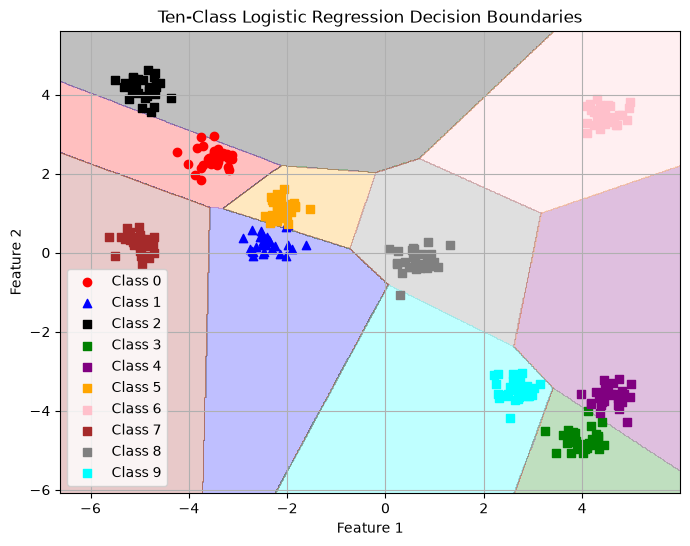

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

model_10class.eval()

# mesh
x_min, x_max = X_10class[:, 0].min() - 1, X_10class[:, 0].max() + 1
y_min, y_max = X_10class[:, 1].min() - 1, X_10class[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 600),
                     np.linspace(y_min, y_max, 600))

with torch.no_grad():
    mesh = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device) # Move mesh to the same device as the model
    logits = model_10class(mesh)
    Z = logits.argmax(dim=1).cpu().numpy().reshape(xx.shape)

# discrete colors (10 distinct)
cmap = ListedColormap([
    "red","blue","black","green","purple",
    "orange","pink","brown","gray","cyan"
])
levels = np.arange(-0.5, 10.5, 1)
norm = BoundaryNorm(levels, cmap.N)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=levels, cmap=cmap, norm=norm, alpha=0.25, antialiased=False)

# your scatter calls here (keep as-is)
plt.scatter(X_10class[y_10class==0, 0], X_10class[y_10class==0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X_10class[y_10class==1, 0], X_10class[y_10class==1, 1], c='blue', marker='^', label='Class 1')
plt.scatter(X_10class[y_10class==2, 0], X_10class[y_10class==2, 1], c='black', marker='s', label='Class 2')
plt.scatter(X_10class[y_10class==3, 0], X_10class[y_10class==3, 1], c='green', marker='s', label='Class 3')
plt.scatter(X_10class[y_10class==4, 0], X_10class[y_10class==4, 1], c='purple', marker='s', label='Class 4')
plt.scatter(X_10class[y_10class==5, 0], X_10class[y_10class==5, 1], c='orange', marker='s', label='Class 5')
plt.scatter(X_10class[y_10class==6, 0], X_10class[y_10class==6, 1], c='pink', marker='s', label='Class 6')
plt.scatter(X_10class[y_10class==7, 0], X_10class[y_10class==7, 1], c='brown', marker='s', label='Class 7')
plt.scatter(X_10class[y_10class==8, 0], X_10class[y_10class==8, 1], c='gray', marker='s', label='Class 8')
plt.scatter(X_10class[y_10class==9, 0], X_10class[y_10class==9, 1], c='cyan', marker='s', label='Class 9')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Ten-Class Logistic Regression Decision Boundaries')
plt.legend()
plt.grid(True)
plt.show()
